In [1]:
plt.savefig('question4_chart.png')

NameError: name 'plt' is not defined

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

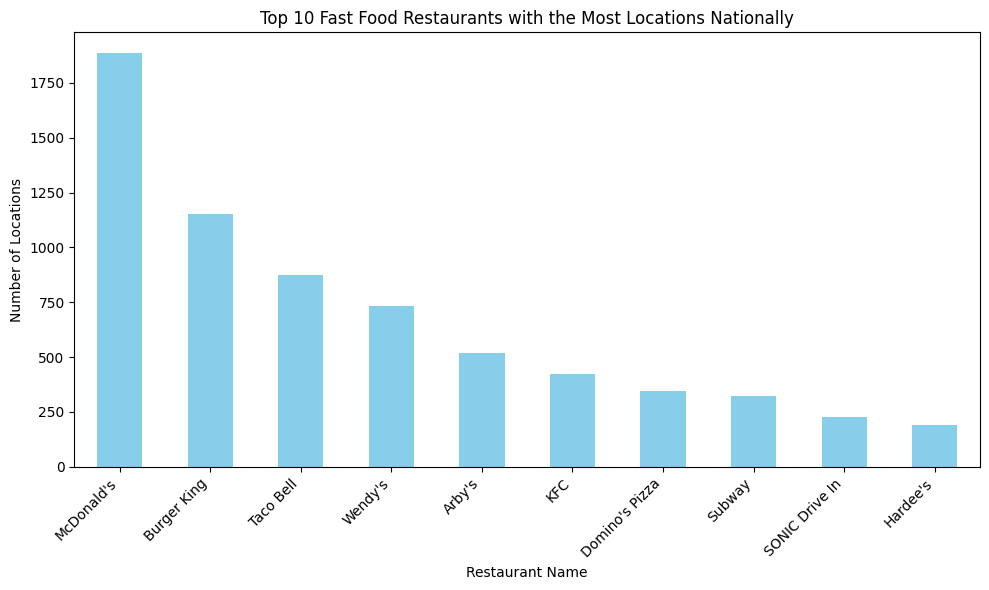

name
McDonald's        1886
Burger King       1154
Taco Bell          873
Wendy's            731
Arby's             518
KFC                421
Domino's Pizza     345
Subway             322
SONIC Drive In     226
Hardee's           192
Name: count, dtype: int64


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the dataset using your exact Kaggle path
df = pd.read_csv('/kaggle/input/datasets/mohdparvez7989/fast-food-data/fast_food_restaurants.csv')

# 2. Get the top 10 fast food chains by location count
top_chains = df['name'].value_counts().head(10)

# 3. Create the bar chart
plt.figure(figsize=(10, 6))
top_chains.plot(kind='bar', color='skyblue')
plt.title('Top 10 Fast Food Restaurants with the Most Locations Nationally')
plt.xlabel('Restaurant Name')
plt.ylabel('Number of Locations')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# 4. Save the chart as an image file
plt.savefig('question4_chart.png')

# 5. Display the chart in the notebook
plt.show()

# 6. Print the text results to help you write your findings later
print(top_chains)

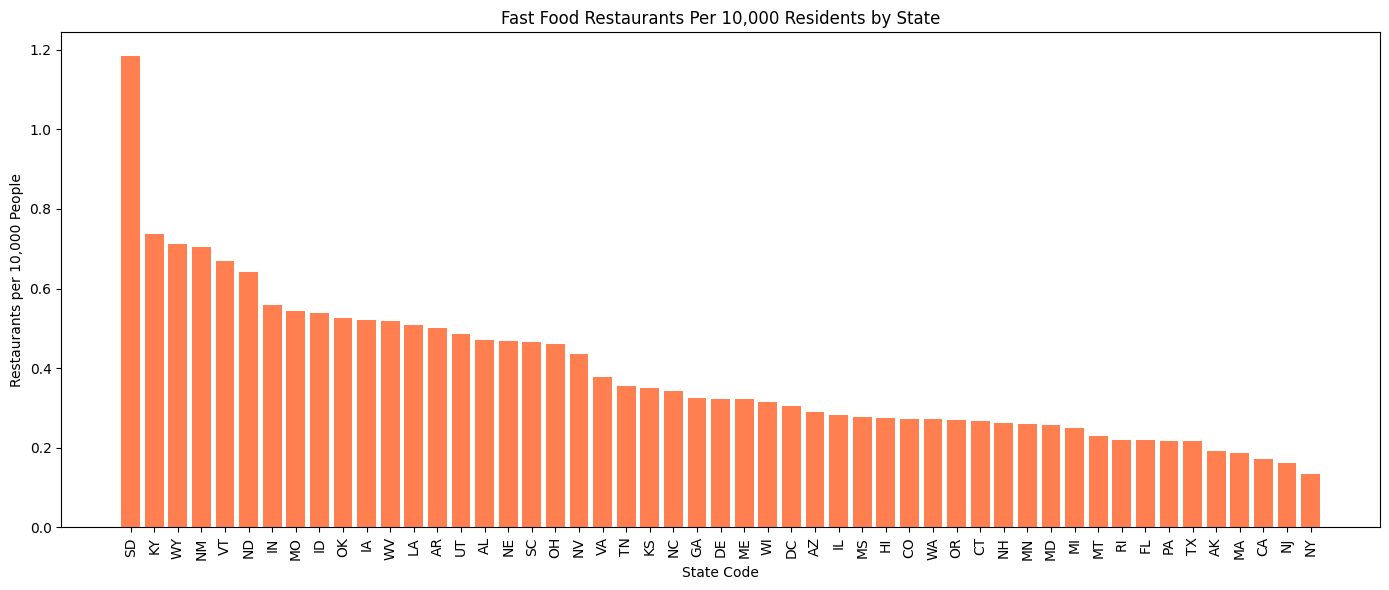

Top 5 States (Highest Density):
    state_code  per_capita
33         SD    1.184210
9          KY    0.736822
43         WY    0.710755
28         NM    0.703653
42         VT    0.668660

Bottom 5 States (Lowest Density):
    state_code  per_capita
50         AK    0.190894
31         MA    0.186346
0          CA    0.170974
27         NJ    0.162558
12         NY    0.133160


In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load data
df_restaurants = pd.read_csv('/kaggle/input/datasets/mohdparvez7989/fast-food-data/fast_food_restaurants.csv')
df_population = pd.read_csv('/kaggle/input/datasets/mohdparvez7989/fast-food-data/state_population.csv')

# 2. Count restaurants per state code
state_counts = df_restaurants['province'].value_counts().reset_index()
state_counts.columns = ['state_code', 'restaurant_count']

# 3. State name to 2-letter code dictionary
state_map = {
    'alabama': 'AL', 'alaska': 'AK', 'arizona': 'AZ', 'arkansas': 'AR', 'california': 'CA',
    'colorado': 'CO', 'connecticut': 'CT', 'delaware': 'DE', 'district of columbia': 'DC',
    'florida': 'FL', 'georgia': 'GA', 'hawaii': 'HI', 'idaho': 'ID', 'illinois': 'IL',
    'indiana': 'IN', 'iowa': 'IA', 'kansas': 'KS', 'kentucky': 'KY', 'louisiana': 'LA',
    'maine': 'ME', 'maryland': 'MD', 'massachusetts': 'MA', 'michigan': 'MI', 'minnesota': 'MN',
    'mississippi': 'MS', 'missouri': 'MO', 'montana': 'MT', 'nebraska': 'NE', 'nevada': 'NV',
    'new hampshire': 'NH', 'new jersey': 'NJ', 'new mexico': 'NM', 'new york': 'NY',
    'north carolina': 'NC', 'north dakota': 'ND', 'ohio': 'OH', 'oklahoma': 'OK', 'oregon': 'OR',
    'pennsylvania': 'PA', 'rhode island': 'RI', 'south carolina': 'SC', 'south dakota': 'SD',
    'tennessee': 'TN', 'texas': 'TX', 'utah': 'UT', 'vermont': 'VT', 'virginia': 'VA',
    'washington': 'WA', 'west virginia': 'WV', 'wisconsin': 'WI', 'wyoming': 'WY', 'puerto rico': 'PR'
}

# 4. Extract total population row (first row) and pivot it
pop_row = df_population.iloc[0]
pop_list = []

for col in df_population.columns:
    col_clean = col.strip().lower()
    if col_clean in state_map:
        val = str(pop_row[col]).replace(',', '') # remove formatting commas if any
        try:
            pop_list.append({'state_code': state_map[col_clean], 'population': float(val)})
        except:
            continue

df_pop_clean = pd.DataFrame(pop_list)

# 5. Merge restaurant counts and population metrics
merged = pd.merge(state_counts, df_pop_clean, on='state_code')

# 6. Calculate per capita density (Restaurants per 10,000 residents)
merged['per_capita'] = (merged['restaurant_count'] / merged['population']) * 10000
merged = merged.sort_values(by='per_capita', ascending=False)

# 7. Create the Bar Chart
plt.figure(figsize=(14, 6))
plt.bar(merged['state_code'], merged['per_capita'], color='coral')
plt.title('Fast Food Restaurants Per 10,000 Residents by State')
plt.xlabel('State Code')
plt.ylabel('Restaurants per 10,000 People')
plt.xticks(rotation=90)
plt.tight_layout()

# 8. Save and display
plt.savefig('question7_chart.png')
plt.show()

# 9. Output metrics for report write-up
print("Top 5 States (Highest Density):\n", merged[['state_code', 'per_capita']].head(5))
print("\nBottom 5 States (Lowest Density):\n", merged[['state_code', 'per_capita']].tail(5))

In [6]:
print("Restaurant provinces look like:\n", df_restaurants['province'].head(3).tolist())
print("Population states look like:\n", df_population.iloc[:, 0].head(3).tolist())
print("Population columns are:", df_population.columns.tolist())

Restaurant provinces look like:
 ['NY', 'OH', 'KY']
Population states look like:
 ['Total']
Population columns are: ['label (grouping)', 'alabama', 'alaska', 'arizona', 'arkansas', 'california', 'colorado', 'connecticut', 'delaware', 'district of columbia', 'florida', 'georgia', 'hawaii', 'idaho', 'illinois', 'indiana', 'iowa', 'kansas', 'kentucky', 'louisiana', 'maine', 'maryland', 'massachusetts', 'michigan', 'minnesota', 'mississippi', 'missouri', 'montana', 'nebraska', 'nevada', 'new hampshire', 'new jersey', 'new mexico', 'new york', 'north carolina', 'north dakota', 'ohio', 'oklahoma', 'oregon', 'pennsylvania', 'rhode island', 'south carolina', 'south dakota', 'tennessee', 'texas', 'utah', 'vermont', 'virginia', 'washington', 'west virginia', 'wisconsin', 'wyoming', 'puerto rico']
